# Two-Island Model

Formålet med denne notebook er at bygge en two-island model og bruge den til inferens. Modellen beskriver to populationer, hvor linjer kan migrere mellem øerne, men der er ingen fælles forfader-population (migration alene opretholder forbindelsen), der er en konstant rate. Dette er den simpleste model som jeg laver først, før jeg går videre til isolation with migration (IM) modellen i notebook 05.

I artiklen af Sørensen et al. 2023 dokumenteres admixture mellem eastern yellow baboons (Mikumi) og Kinda bavianeren er tæt forbundet og der er geneflow mellem dem. Two island modellen kan give en konstant migrationsestimat. Jeg kommer i denne notebook ind på følgende:

1. Byg two-island model
2. Simuler testdata med msprime
3. Joint-probability graf og SFS inference med SVGD
4. Anvende modellen på bavian-data (Eastern yellow vs. Kinda) fra notebook 03
5. Visualisering

Indlæs data fra notebook 03

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # Brug kun GPU 0 (eller fjern linjen på CPU-maskiner)
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"
# phasic importeres først for at sætte JAX-backend korrekt

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
import msprime

from vscodenb import set_vscode_theme
all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
sns.set_palette("tab10")


MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)


print("Imports OK")

Imports OK


Antal vertices i to-island grafen: 21
Antal parametre: 3


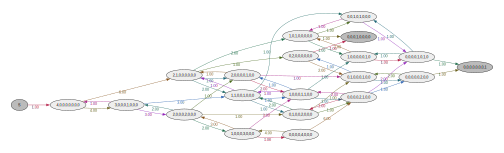

In [2]:
nr_samples = 4

indexer = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ]
)

# Startstate: alle lineages er singletons i population 1
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1, in_pop=1)] = nr_samples

@with_ipv(ipv)
def two_island(state, indexer=None):
    # To-ø model med tre parametre:
    #     theta[0] = coalescence-rate population 1 (1/N1)
    #     theta[1] = coalescence-rate population 2 (1/N2)
    #     theta[2] = migrationsrate pr. lineage pr. tidsenhed
    transitions = []
    if state.sum() <= 1:
        return transitions

    # Coalescence inden for hver population
    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if pi.in_pop != pj.in_pop:
            continue
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples:
            continue
        k = indexer.lineages.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        # Placér i det tilsvarende coalescence-parameter-slot
        coeff = [rate if pi.in_pop == 1 else 0,
                 rate if pi.in_pop == 2 else 0,
                 0]
        transitions.append([new, coeff])

    # Migration (symmetrisk rate m)
    for i in range(indexer.state_length):
        if state[i] == 0:
            continue
        pi = indexer.lineages.index_to_props(i)
        other = 2 if pi.in_pop == 1 else 1
        new = state.copy()
        new[i] -= 1
        k = indexer.lineages.props_to_index(descendants=pi.descendants, in_pop=other)
        new[k] += 1
        transitions.append([new, [0, 0, state[i]]])

    return transitions

graph_2i = Graph(two_island, indexer=indexer)
print(f"Antal vertices i to-island grafen: {graph_2i.vertices_length()}")
print(f"Antal parametre: {graph_2i.param_length()}")
graph_2i.plot(nodesep=0.4, wrap=False)

## 2. Teoretiske egenskaber

Med sande parametre $(N_1, N_2, m) =(1,2,0.5)$ beregner jeg forventet TMRCA og SFS under modellen.

In [3]:
# Sande parametre (i coalescent-enheder)
N1_true, N2_true, m_true = 1.0, 2.0, 0.5
true_theta = [1/N1_true, 1/N2_true, m_true]
graph_2i.update_weights(true_theta)

print(f"Forventet TMRCA:     {graph_2i.expectation():.4f}")
print(f"Varians på TMRCA:    {graph_2i.variance():.4f}")

Forventet TMRCA:     3.8231
Varians på TMRCA:    12.5314


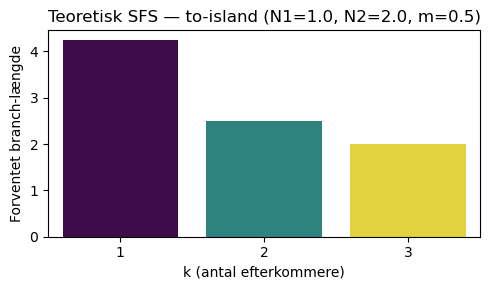

In [4]:
# Beregn forventet SFS ved reward-transform
# Rewarden tæller tid tilbragt med en lineage der har præcis i efterkommere
state_mat = graph_2i.states()
descendants_rewards = []
for k_val in range(1, nr_samples):
    r = np.zeros(state_mat.shape[0])
    for row_idx in range(state_mat.shape[0]):
        for col_idx in range(indexer.state_length):
            props = indexer.lineages.index_to_props(col_idx)
            if props.descendants == k_val:
                r[row_idx] += state_mat[row_idx, col_idx]
    descendants_rewards.append(r)

sfs = np.array([graph_2i.expectation(rewards=r) for r in descendants_rewards])
x = np.arange(1, nr_samples)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=x, y=sfs, hue=x, width=0.8, palette="viridis", legend=False, ax=ax)
ax.set_xlabel("k (antal efterkommere)")
ax.set_ylabel("Forventet branch-længde")
ax.set_title(f"Teoretisk SFS — to-island (N1={N1_true}, N2={N2_true}, m={m_true})")
plt.tight_layout()
plt.show()

# 3. Joint probability graf — diskrete mutations-observationer

For at kunne fitte modellen til rigtige SNP-data laver jeg en joint probability graf, der kobler coalescent-modellen til en Poisson-mutations-proces.

Hver observation er et tupel $(k_1,k_2,...,k_{n-1})$ som fortæller hvor mange singletons, doubletons osv. en lokus-konfiguration har. Mutationsraten indgår som en ekstra parameter.

In [5]:
mutation_rate = 1.0   # i coalescent-enheder — svarer til theta = 4*N*mu*L
joint_graph = graph_2i.joint_prob_graph(
    indexer,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate,
)

true_theta_joint = [1/N1_true, 1/N2_true, m_true, mutation_rate]
joint_graph.update_weights(true_theta_joint)

tbl = joint_graph.joint_prob_table()
print(f"Antal unikke observation-mønstre: {len(tbl)}")
print(f"Deficit (afkortnings-bias): {(1 - tbl['prob'].sum()).item():.4f}")
tbl.head(10)

Antal unikke observation-mønstre: 7
Deficit (afkortnings-bias): 0.8396


,descendants_1,descendants_2,descendants_3,descendants_4,prob
t_vertex_index,,,,,
91,0,0,0,0,0.058421
92,0,1,0,0,0.020558
93,1,0,0,0,0.050526
94,0,0,1,0,0.012195
95,1,0,1,0,0.008389
96,1,1,0,0,0.009382
97,0,1,1,0,0.000966


# 4. Simuler testdata med msprime

Før jeg bruger bavian-data, laver jeg simuleret data med kendte parametre. Dette er den bedste måde at verificere, at min inferens er troværdig.

In [6]:
import msprime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)

In [7]:
def pairs_in_range(nums, diff_lo, diff_hi):
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs

df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


In [8]:
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


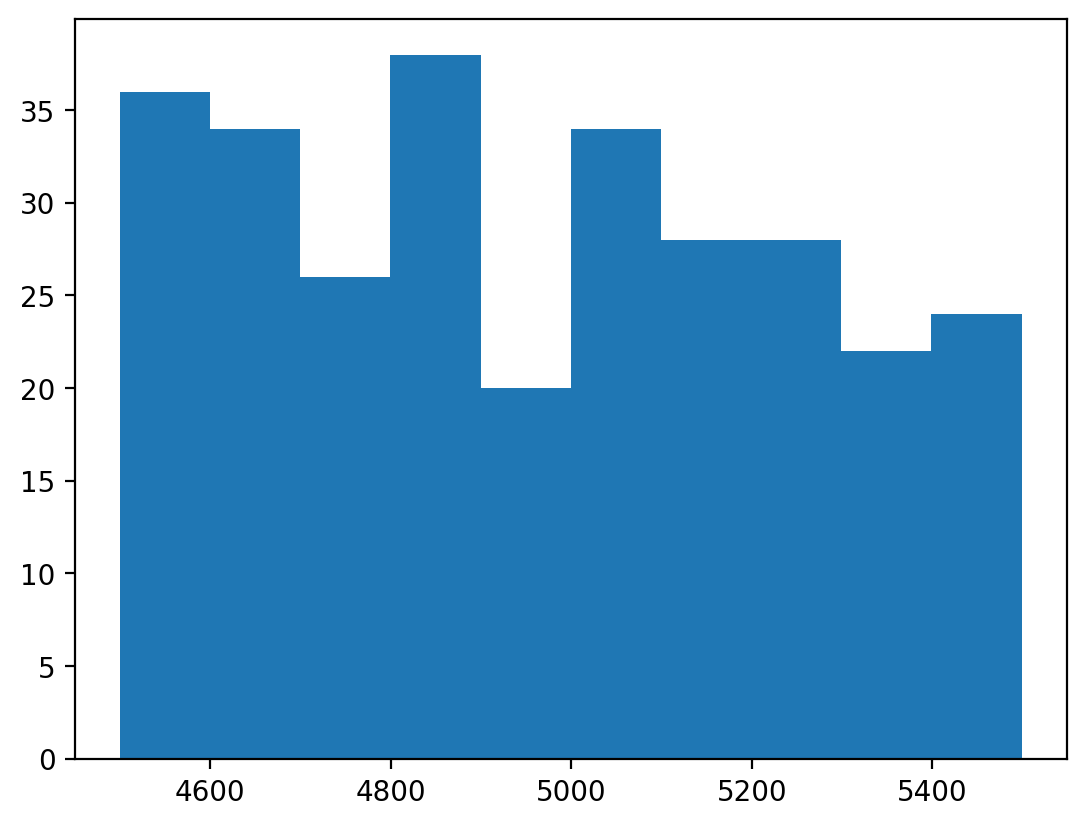

In [9]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [10]:
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [11]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



# 6. Anvend modellen på bavian-data

Jeg indlæser de gemte derived-count-filer fra notebook 03 og fitter to-island modellen på *Eastern yellow (Mikumi)* data. Modellen antager at alle samples er trukket fra en population og at den anden population kun bidrager via migration.

In [12]:
def load_baboon_ktons(path, n_samples_use, seed=0):
    p = Path(path)
    if not p.exists():
        print(f"[advarsel] {p} findes ikke — kør notebook 03 først.")
        return None
    df = pd.read_csv(p)
    df = df[df["nr_samples"] >= n_samples_use].copy()
    if len(df) == 0:
        print(f"[advarsel] {p} har ingen varianter med nr_samples >= {n_samples_use}")
        return None
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_samples_use,
    )
    k = k[(k > 0) & (k < n_samples_use)]
    return k

k_east = load_baboon_ktons(OUT_DIR / "derived_counts_yellow_east.csv", nr_samples)

if k_east is not None:
    print(f"Antal segregerende SNPs efter subsampling (n={nr_samples}): {len(k_east):,}")

    feature_cols = [c for c in tbl.columns if c.startswith("descendants")]
    allowed = set(tuple(int(x) for x in r) for r in tbl[feature_cols].values)
    obs_baboon = []
    for k in k_east:
        o = [0] * len(feature_cols)
        if 0 < k - 1 < len(o):
            o[k - 1] = 1
        if tuple(o) in allowed:
            obs_baboon.append(o)
    print(f"Heraf brugbare under model: {len(obs_baboon):,}")

Antal segregerende SNPs efter subsampling (n=5): 394,120
Heraf brugbare under model: 341,996


In [13]:
if k_east is not None and len(obs_baboon) > 1000:
    rng = np.random.default_rng(1)
    if len(obs_baboon) > 5000:
        idx = rng.choice(len(obs_baboon), 5000, replace=False)
        obs_baboon_use = [obs_baboon[i] for i in idx]
    else:
        obs_baboon_use = obs_baboon

    svgd_baboon = joint_graph.svgd(
        observed_data=obs_baboon_use,
        fixed=[(3, mutation_rate)],
        n_iterations=150,
        n_particles=80,
        prior=[
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.1, 5.0]),
            GaussPrior(ci=[0.0, 3.0]),
            None,
        ],
        learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
    )
    svgd_baboon.summary(ci_method="hpd", ci_level=0.95)

Parameter  Fixed      MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No         7.2231     5.3923     1.4184     3.4052       7.2231      
1          No         3.1684     2.8352     1.1839     0.7334       4.8540      
2          No         2.8509     1.8486     0.8383     0.2827       2.9017      
3          Yes        1.0000     NA         NA         NA           NA          

Particles: 80, Iterations: 150


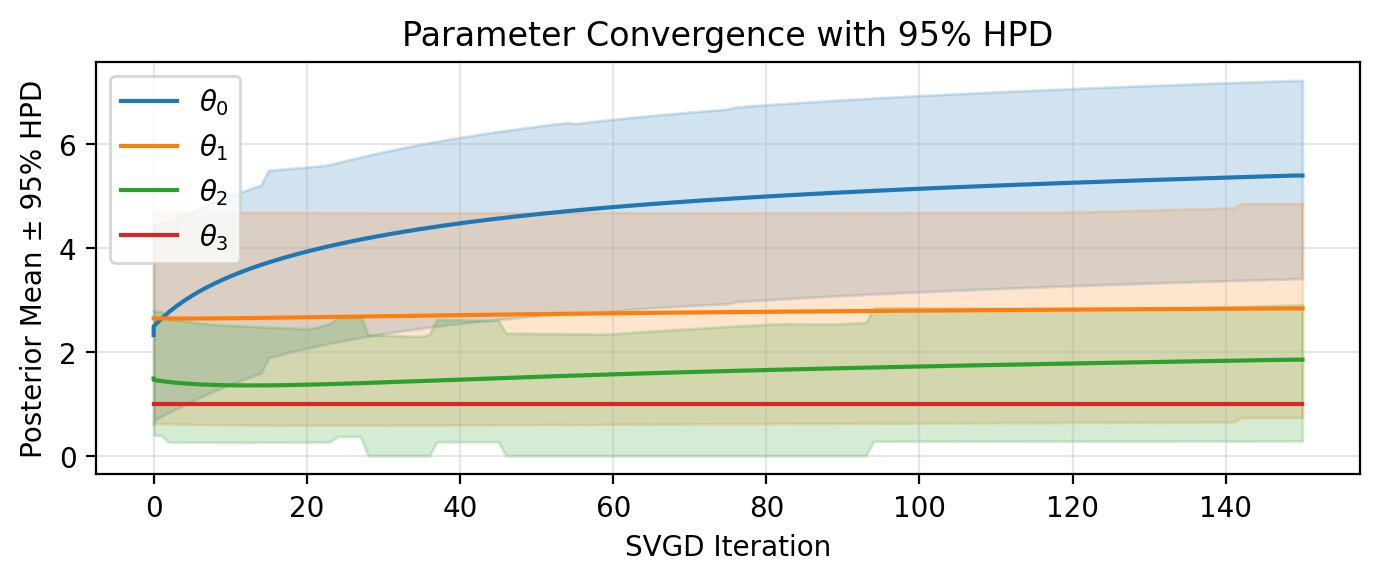

<Figure size 640x480 with 0 Axes>

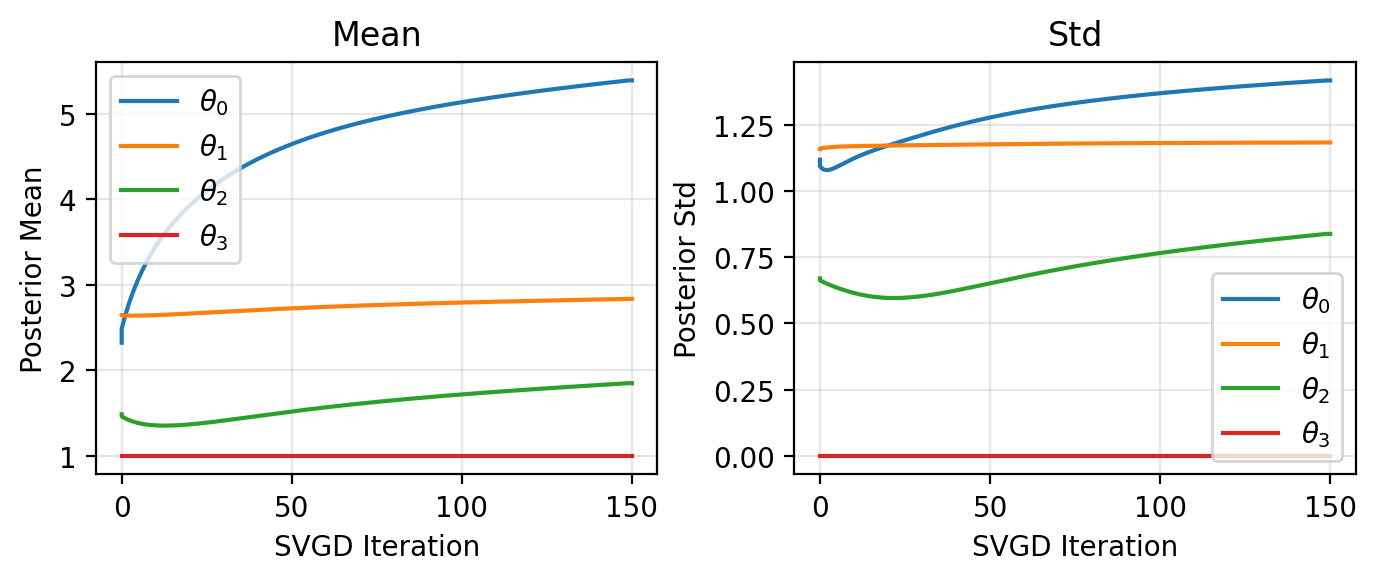

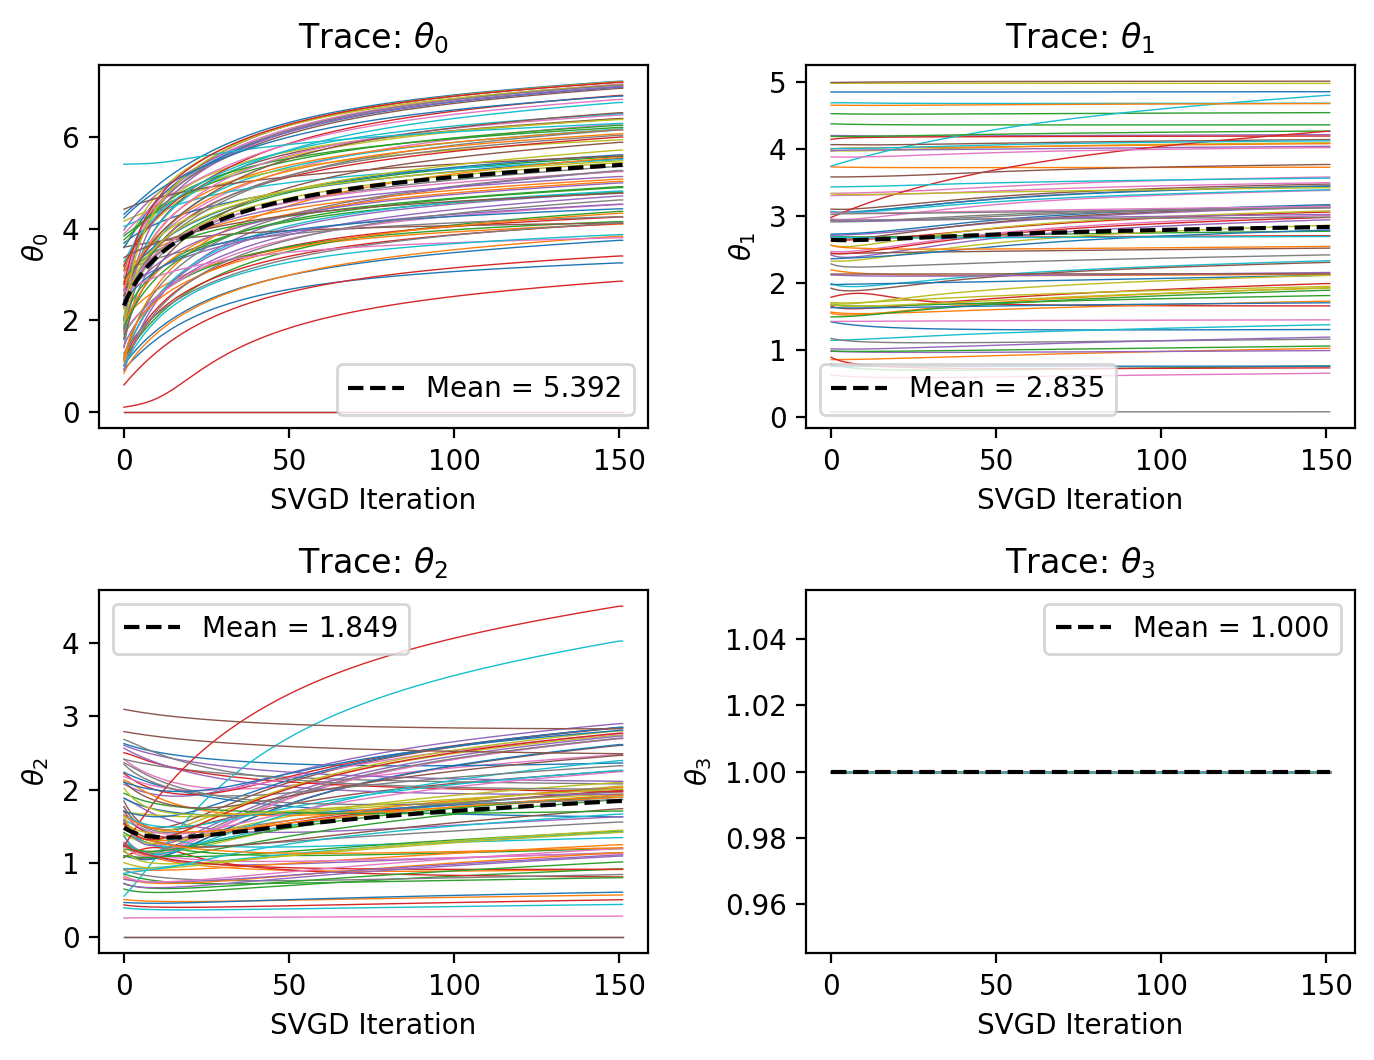

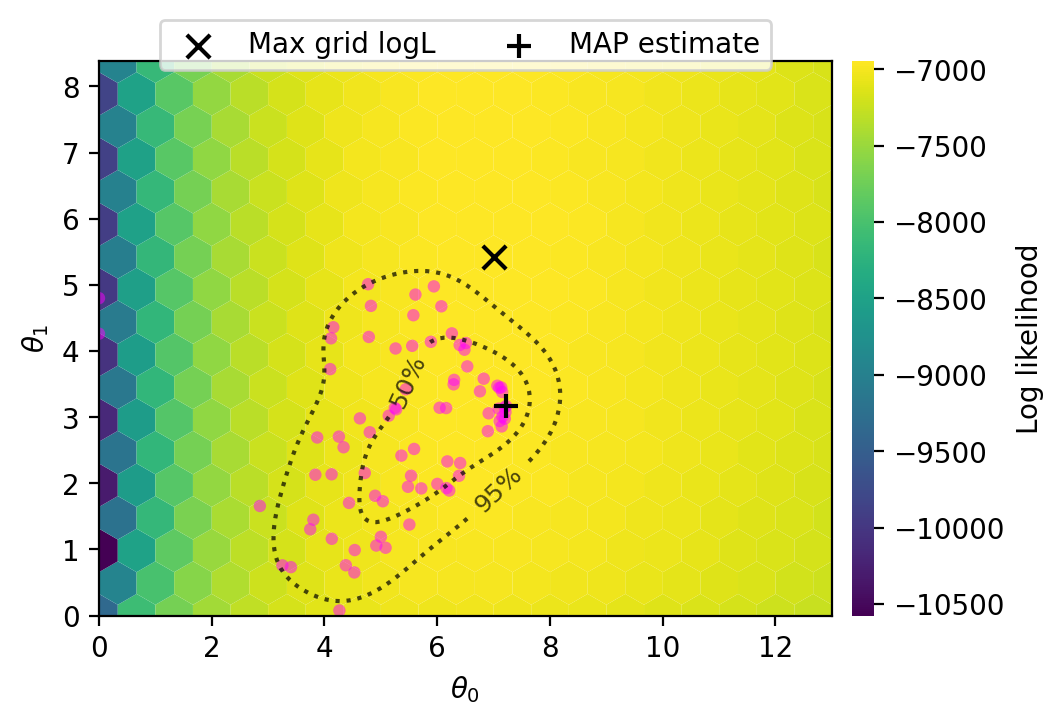

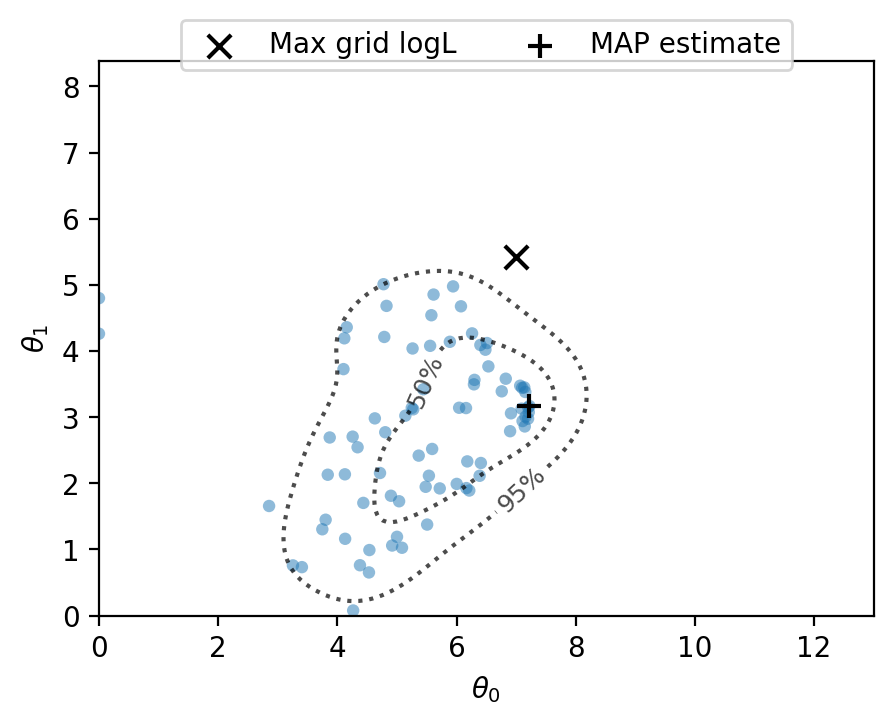

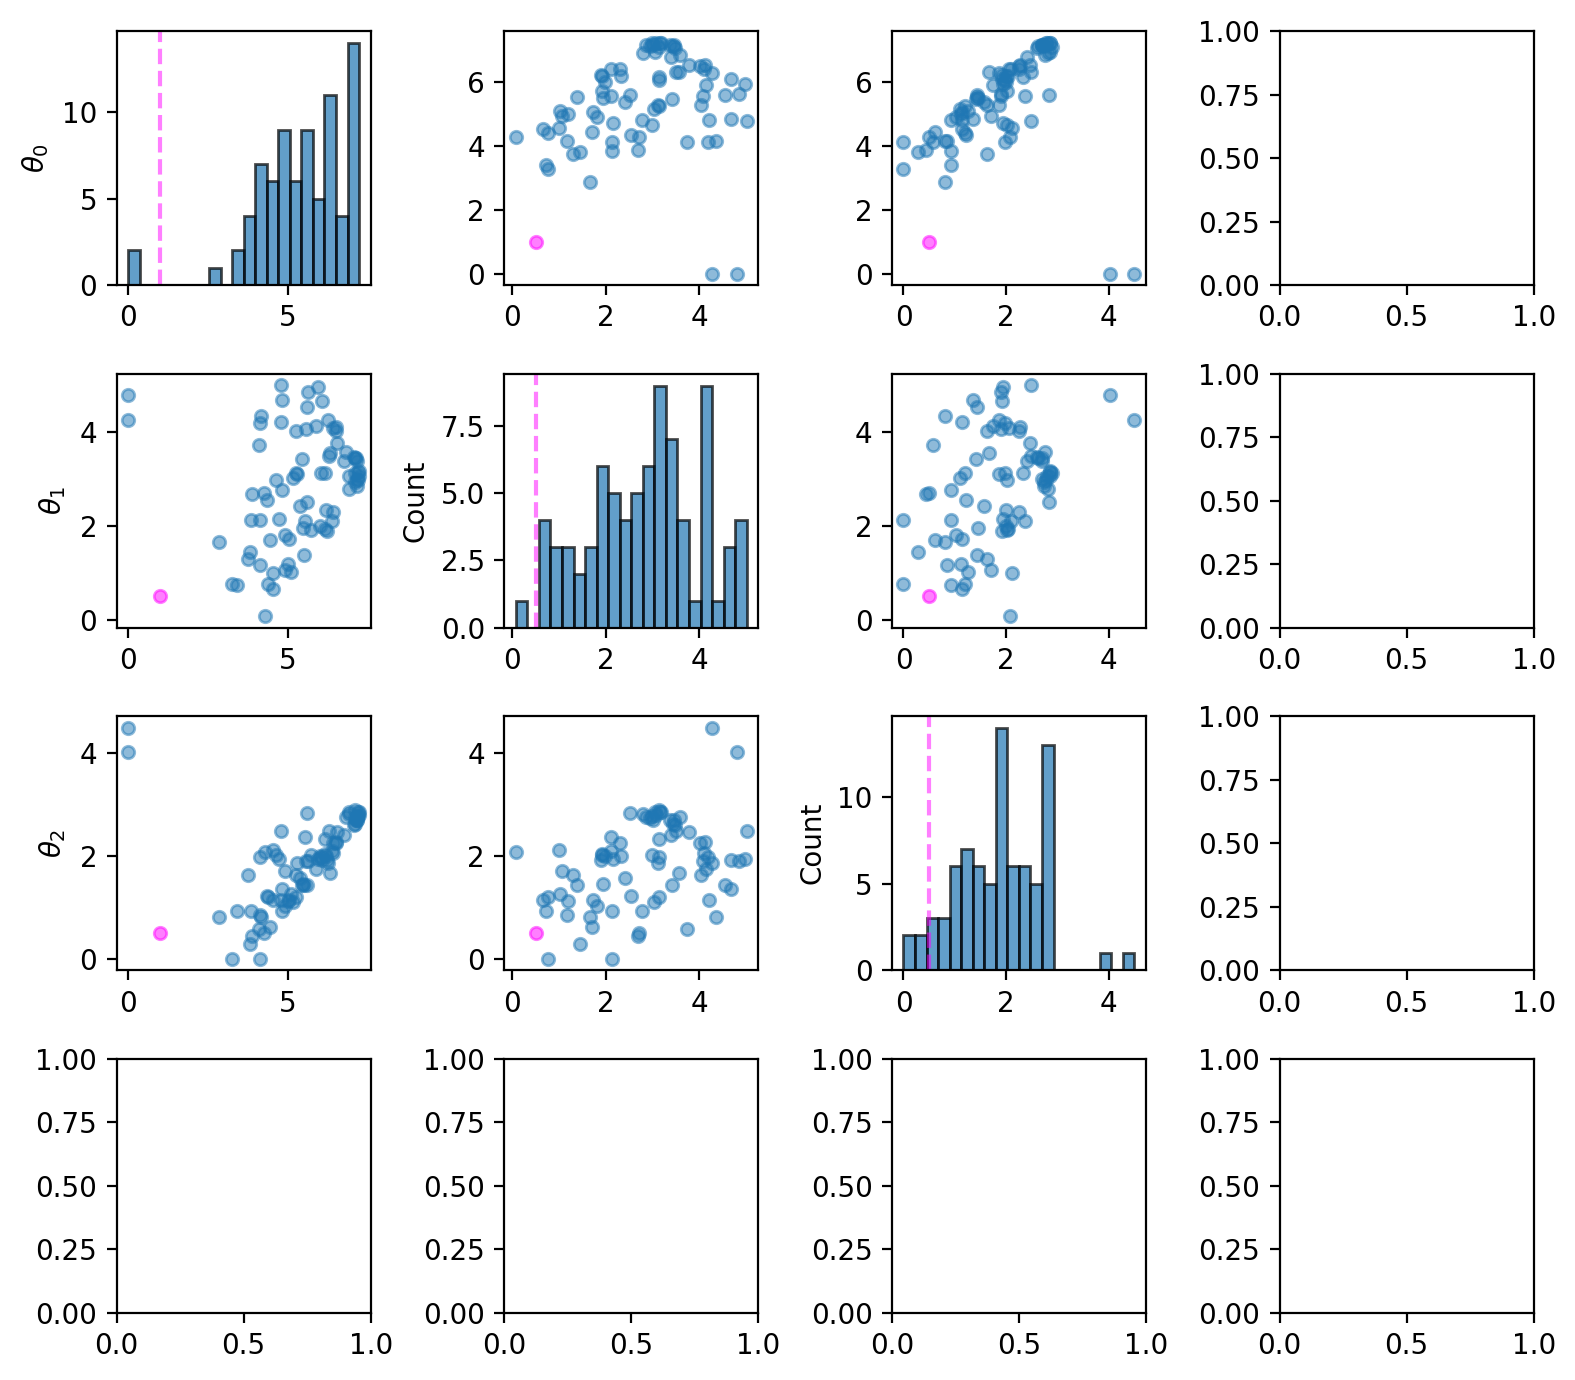

<Figure size 640x480 with 0 Axes>

In [14]:
if k_east is not None and len(obs_baboon) > 1000:
    svgd_baboon.plot_ci(ci_method="hpd")
    plt.suptitle("Posterior CI — Eastern yellow bavian")
    plt.show()

    svgd_baboon.plot_convergence();
    
    svgd_baboon.plot_trace()

    svgd_baboon.plot_hdr()

    svgd_baboon.plot_hdr(hexgrid=False) ;

    svgd_baboon.plot_pairwise(true_theta=true_theta)
    plt.suptitle("Posterior pairwise — Eastern yellow bavian", y=1.02)
    plt.show()

7. Fortolkning

Parametrene i coalescent-enheder kan konverteres til demografiske enheder ved at vælge en reference-populationsstørrelse $N_{ref}$:

- $N_i = \frac{1}{\left(\frac{1}{N_i}\right)\cdot 2N_{\mathrm{ref}}}$ (haploid diffusions-enheder)
- $M_{i \to j} = \frac{m}{2N_{\mathrm{ref}}}$(per lineage per generation)

For at få en absolut $N_{ref}$ bruger jeg heterozygositeten $\pi \approx 4N_{ref} \mu$ og mutationsraten fra Sørensen et al. ($\mu = 0.9 \times 10^{-8}$ per site per generation).

In [18]:
pi_file = OUT_DIR / "pi_per_population.csv"
if pi_file.exists():
    pi_df = pd.read_csv(pi_file, index_col=0)
    if "Eastern yellow (Mikumi)" in pi_df.index:
        pi_east = pi_df.loc["Eastern yellow (Mikumi)", "pi"]
        Ne_ref = pi_east / (4 * MUT_RATE)
        print(f"pi (Eastern yellow):  {pi_east:.6f}")
        print(f"Implied Ne_ref:       {Ne_ref:,.0f}")
        if "svgd_baboon" in dir():
            res = svgd_baboon.get_results()
            theta_mean = res["theta_mean"]
            N1_est = (1 / theta_mean[0]) * Ne_ref
            N2_est = (1 / theta_mean[1]) * Ne_ref
            m_est_gen = theta_mean[2] / (2 * Ne_ref)
            print("\nEstimater (posterior mean):")
            print(f"  N1 (Eastern yellow):  {N1_est:,.0f}")
            print(f"  N2 (Kinda-lignende):  {N2_est:,.0f}")
            print(f"  Migration rate:       {m_est_gen:.2e} / generation")

pi (Eastern yellow):  0.002584
Implied Ne_ref:       71,789

Estimater (posterior mean):
  N1 (Eastern yellow):  13,313
  N2 (Kinda-lignende):  25,321
  Migration rate:       1.29e-05 / generation


I næste notebook (05 — IM-model) udvider jeg dette ved at tilføje et split-tidspunkt for to populationer fra en fælles forfader. Det kræver time inhomogeneity, som jeg kommer nærmere ind på i notebook 06.